<a href="https://colab.research.google.com/github/Trevorkaaya21/CIFAR-10-neural-networks-comparisons/blob/main/CIFAR10_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSC 485 Project 2 — CIFAR-10 Image Classification


In [ ]:
#downloading the libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

## Part 1: Setup and Data Exploration

### Load CIFAR-10 and display samples

In [ ]:
#loading CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


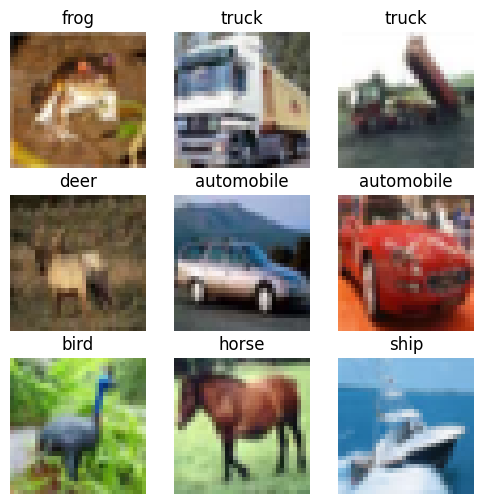

In [ ]:
#displaying 9 sample images
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.show()

## Part 2: Preprocessing
Creating **training / validation / testing** subsets
Splitting the original training set into **45,000 train** and **5,000 validation**.

In [ ]:
#normalize to [0, 1] and then create a validation split
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Create validation split
x_val = x_train[45000:]
y_val = y_train[45000:]

x_train = x_train[:45000]
y_train = y_train[:45000]

Function to Plot

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{title} Loss')
    plt.legend()

    plt.show()

## Part 3: Basic MLP (Baseline)

In [ ]:
mlp = keras.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(10, activation='softmax')
])

mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mlp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │        30,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,730 (120.04 KB)

 Trainable params: 30,730 (120.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_mlp = mlp.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2817 - loss: 2.0619 - val_accuracy: 0.3126 - val_loss: 1.9723
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3489 - loss: 1.8939 - val_accuracy: 0.3440 - val_loss: 1.8960
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3640 - loss: 1.8523 - val_accuracy: 0.3312 - val_loss: 1.9358
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3674 - loss: 1.8426 - val_accuracy: 0.3774 - val_loss: 1.8060
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3679 - loss: 1.8408 - val_accuracy: 0.3390 - val_loss: 1.9406
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3784 - loss: 1.8189 - val_accuracy: 0.3782 - val_loss: 1.8227
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3782 - loss: 1.8117 - val_accuracy: 0.3404 - val_loss: 1.9136
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3801 - loss: 1.8264 - 

Plotting he accuracy and loss

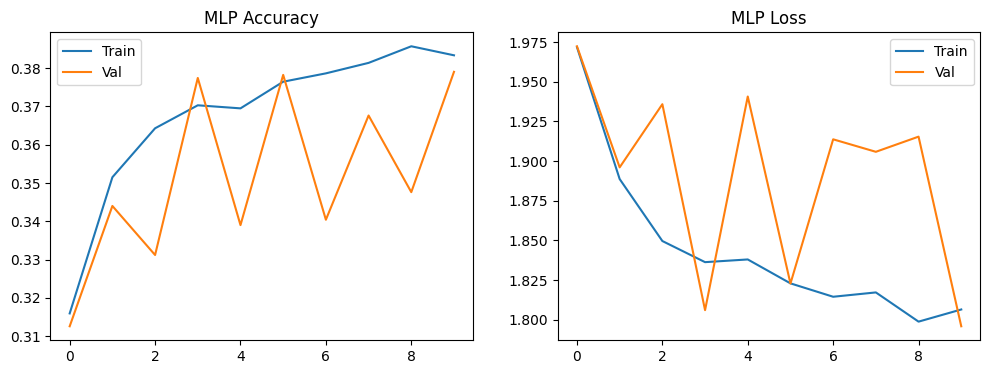

In [ ]:
plot_history(history_mlp, "MLP")

Printing the test accuracy

In [ ]:
mlp_test_acc = mlp.evaluate(x_test, y_test, verbose=0)[1]
print("MLP Test Accuracy:", mlp_test_acc)

MLP Test Accuracy: 0.37700000405311584


## Part 4: Regular ANN

In [ ]:
ann = keras.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_ann = ann.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2505 - loss: 2.0613 - val_accuracy: 0.3204 - val_loss: 1.8751
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3457 - loss: 1.8281 - val_accuracy: 0.3564 - val_loss: 1.8202
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3586 - loss: 1.7919 - val_accuracy: 0.3730 - val_loss: 1.7678
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3718 - loss: 1.7639 - val_accuracy: 0.3404 - val_loss: 1.8931
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3720 - loss: 1.7555 - val_accuracy: 0.3762 - val_loss: 1.7655
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3810 - loss: 1.7412 - val_accuracy: 0.3876 - val_loss: 1.7559
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3847 - loss: 1.7392 - val_accuracy: 0.3824 - val_loss: 1.7613
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3897 - loss: 1.7230 - 

Plotting the accuracy and loss for ANN

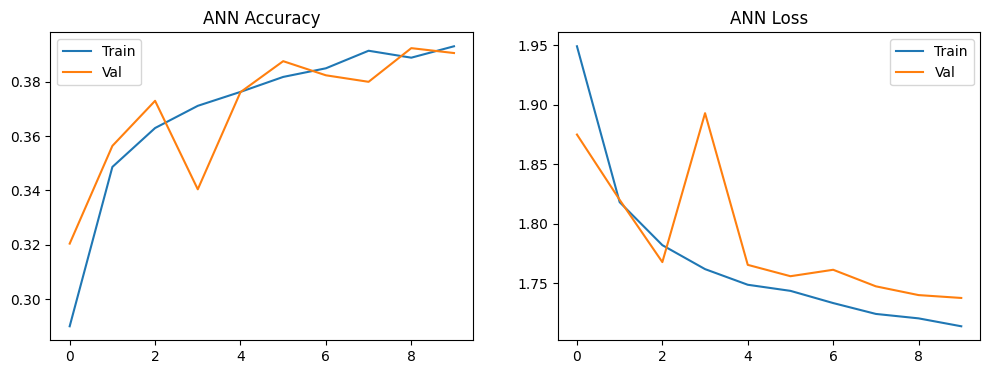

In [ ]:
plot_history(history_ann, "ANN")

Printing the test accuracy

In [ ]:
ann_test_acc = ann.evaluate(x_test, y_test, verbose=0)[1]
print("ANN Test Accuracy:", ann_test_acc)

ANN Test Accuracy: 0.3874000012874603


## Part 5: Deep Neural Network (DNN)

In [ ]:
dnn = keras.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

dnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_dnn = dnn.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1782 - loss: 2.1898 - val_accuracy: 0.2768 - val_loss: 1.9427
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2390 - loss: 2.0025 - val_accuracy: 0.3120 - val_loss: 1.8977
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2580 - loss: 1.9765 - val_accuracy: 0.3066 - val_loss: 1.8924
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2680 - loss: 1.9531 - val_accuracy: 0.3258 - val_loss: 1.8724
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2781 - loss: 1.9330 - val_accuracy: 0.3132 - val_loss: 1.8873
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2875 - loss: 1.9230 - val_accuracy: 0.3320 - val_loss: 1.8603
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2856 - loss: 1.9225 - val_accuracy: 0.3244 - val_loss: 1.8614
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2927 - loss: 1.9119 - 

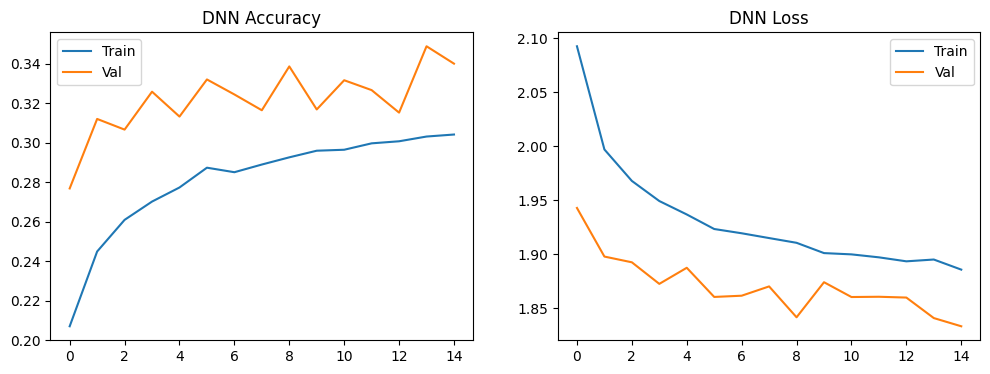

In [ ]:
plot_history(history_dnn, "DNN")

In [ ]:
dnn_test_acc = dnn.evaluate(x_test, y_test, verbose=0)[1]
print("DNN Test Accuracy:", dnn_test_acc)

DNN Test Accuracy: 0.34540000557899475


## Part 6: Convolutional Neural Network (CNN)


In [ ]:
cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = cnn.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3913 - loss: 1.6795 - val_accuracy: 0.5968 - val_loss: 1.1575
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6060 - loss: 1.1222 - val_accuracy: 0.6486 - val_loss: 1.0056
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6716 - loss: 0.9489 - val_accuracy: 0.6624 - val_loss: 0.9762
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7090 - loss: 0.8436 - val_accuracy: 0.6886 - val_loss: 0.9071
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7389 - loss: 0.7479 - val_accuracy: 0.6884 - val_loss: 0.8997
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7602 - loss: 0.6762 - val_accuracy: 0.7034 - val_loss: 0.8875
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7882 - loss: 0.6006 - val_accuracy: 0.7080 - val_loss: 0.8754
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8183 - loss: 0.5305 

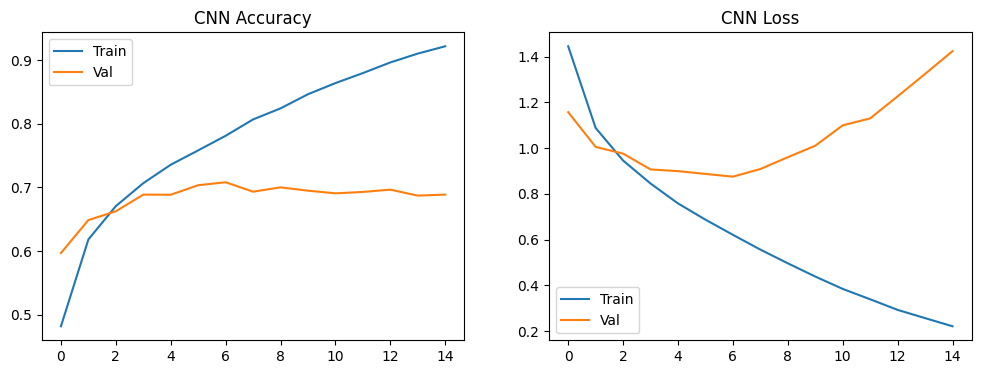

In [ ]:
plot_history(history_cnn, "CNN")

In [ ]:
cnn_test_acc = cnn.evaluate(x_test, y_test, verbose=0)[1]
print("CNN Test Accuracy:", cnn_test_acc)

CNN Test Accuracy: 0.6814000010490417


## Part 7: Pretrained Model (MobileNetV2)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

Extra preprocessing for the pretrained model

In [ ]:
x_train_resized = tf.image.resize(x_train, (96,96))
x_val_resized = tf.image.resize(x_val, (96,96))
x_test_resized = tf.image.resize(x_test, (96,96))

Phase 1- training the top layers

In [ ]:
base_model = keras.applications.MobileNetV2(
    input_shape=(96,96,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [ ]:
pretrained = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

pretrained.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_pre = pretrained.fit(
    x_train_resized, y_train,
    validation_data=(x_val_resized, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.6987 - loss: 0.8759 - val_accuracy: 0.7844 - val_loss: 0.6161
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8055 - loss: 0.5542 - val_accuracy: 0.8046 - val_loss: 0.5644
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8269 - loss: 0.4892 - val_accuracy: 0.8022 - val_loss: 0.5729
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8468 - loss: 0.4311 - val_accuracy: 0.7968 - val_loss: 0.5799
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8617 - loss: 0.3942 - val_accuracy: 0.8038 - val_loss: 0.5718
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8725 - loss: 0.3523 - val_accuracy: 0.7994 - val_loss: 0.5849
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8883 - loss: 0.3154 - val_accuracy: 0.8002 - val_loss: 0.6151
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8980 -

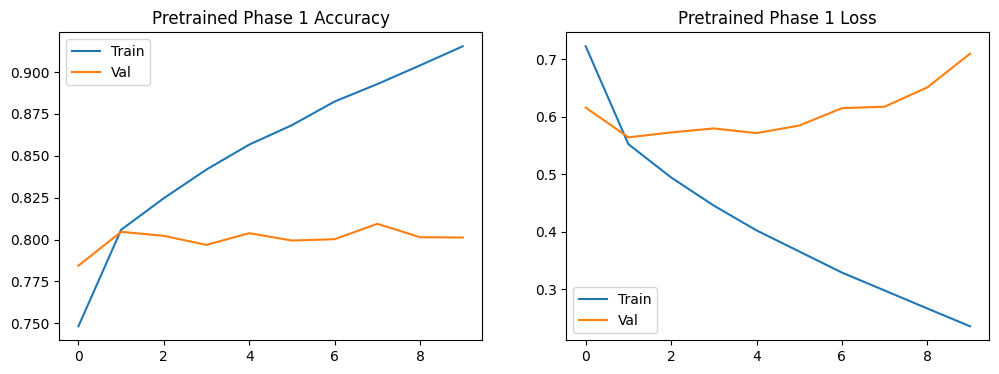

In [ ]:
plot_history(history_pre, "Pretrained Phase 1")

Phase 2 - Fine Tuning

In [ ]:
base_model.trainable = True

pretrained.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fine = pretrained.fit(
    x_train_resized, y_train,
    validation_data=(x_val_resized, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 128s 58ms/step - accuracy: 0.6484 - loss: 2.8169 - val_accuracy: 0.7890 - val_loss: 1.0769
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.8118 - loss: 1.0390 - val_accuracy: 0.8320 - val_loss: 0.8936
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.8533 - loss: 0.6895 - val_accuracy: 0.8596 - val_loss: 0.6959
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.8737 - loss: 0.5082 - val_accuracy: 0.8688 - val_loss: 0.6002
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.8937 - loss: 0.3782 - val_accuracy: 0.8798 - val_loss: 0.5202


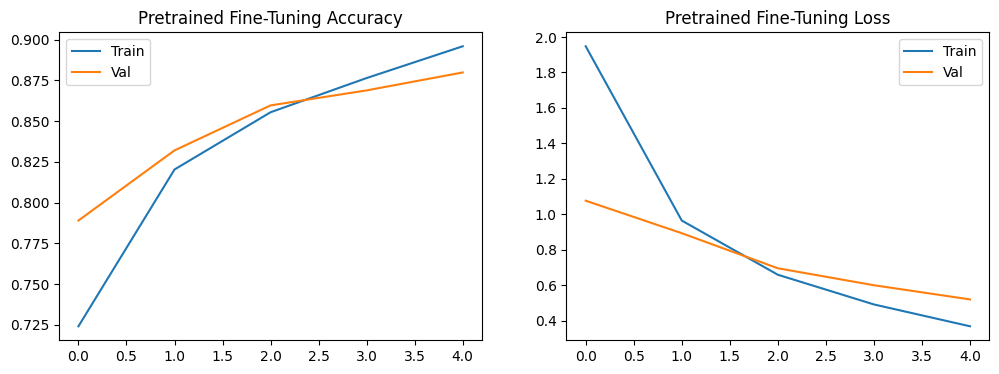

In [ ]:
plot_history(history_fine, "Pretrained Fine-Tuning")

In [ ]:
# Saving as a PDF

def colab2pdf():
  ENABLE=True # @param {type:"boolean"}
  if ENABLE:
    !apt-get install librsvg2-bin
    import os, datetime, json, locale, pathlib, urllib, requests, werkzeug, nbformat, google, yaml, warnings
    locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')
    NAME = pathlib.Path(werkzeug.utils.secure_filename(urllib.parse.unquote(requests.get(f"http://{os.environ['COLAB_JUPYTER_IP']}:{os.environ['KMP_TARGET_PORT']}/api/sessions").json()[0]["name"])))
    TEMP = pathlib.Path("/content/pdfs") / f"{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}_{NAME.stem}"; TEMP.mkdir(parents=True, exist_ok=True)
    NB = [cell for cell in nbformat.reads(json.dumps(google.colab._message.blocking_request("get_ipynb", timeout_sec=600)["ipynb"]), as_version=4).cells if "--Colab2PDF" not in cell.source]
    warnings.filterwarnings('ignore', category=nbformat.validator.MissingIDFieldWarning)
    with (TEMP / f"{NAME.stem}.ipynb").open("w", encoding="utf-8") as nb_copy: nbformat.write(nbformat.v4.new_notebook(cells=NB or [nbformat.v4.new_code_cell("#")]), nb_copy)
    if not pathlib.Path("/usr/local/bin/quarto").exists():
      !wget -q "https://quarto.org/download/latest/quarto-linux-amd64.deb" -P {TEMP} && dpkg -i {TEMP}/quarto-linux-amd64.deb > /dev/null && quarto install tinytex --update-path --quiet
      with (TEMP / "config.yml").open("w", encoding="utf-8") as file: yaml.dump({'include-in-header': [{"text": r"\usepackage{fvextra}\DefineVerbatimEnvironment{Highlighting}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines,breakanywhere,commandchars=\\\{\}}"}],'include-before-body': [{"text": r"\DefineVerbatimEnvironment{verbatim}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines}"}]}, file)
      !quarto render {TEMP}/{NAME.stem}.ipynb --metadata-file={TEMP}/config.yml --to pdf -M latex-auto-install -M margin-top=1in -M margin-bottom=1in -M margin-left=1in -M margin-right=1in --quiet
      google.colab.files.download(str(TEMP / f"{NAME.stem}.pdf"))
colab2pdf()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  librsvg2-bin
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 1,871 kB of archives.
After this operation, 6,019 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 librsvg2-bin amd64 2.52.5+dfsg-3ubuntu0.2 [1,871 kB]
Fetched 1,871 kB in 2s (795 kB/s)
Selecting previously unselected package librsvg2-bin.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack .../librsvg2-bin_2.52.5+dfsg-3ubuntu0.2_amd64.deb ...
Unpacking librsvg2-bin (2.52.5+dfsg-3ubuntu0.2) ...
Setting up librsvg2-bin (2.52.5+dfsg-3ubuntu0.2) ...
Processing triggers for man-db (2.10.2-1) ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>